In [1]:
%matplotlib widget

# PPO training

In [2]:
import importlib
import jax

import flock.env as flock_env
import flock.env.core as flock_core
import flock.env.obs as flock_obs
import flock.train.ppo as flock_ppo
import flock.train.ppo.policy as flock_policy

for module in (flock_obs, flock_core, flock_policy, flock_ppo, flock_env):
    importlib.reload(module)

from flock.env.types import Bush
from flock.env import EnvConfig, run_episode
from flock.env.rules import PredatorPrey
from flock.env.viz import animate, plot_stats
from flock.train.ppo import PPOConfig, Trainee, PredatorReward, PreyReward, make_policy, train

In [3]:
rules = PredatorPrey(
    n_predators=3,
    n_prey=40,
    catch_radius=0.3,
    k_teammates=4,
    k_opponents=5,
    max_speed_predator=2.0,
    max_speed_prey=1.5,
    max_accel_predator=0.5,
    max_accel_prey=1.0,
)
env_cfg = EnvConfig(
    max_steps=300,
    dt=0.1,
    bushes=(Bush(x=2.0, y=3.0, radius=1.0), Bush(x=7.0, y=8.0, radius=1.0)),
)

def make_policies(seed=42):
    key = jax.random.key(seed)
    k1, k2 = jax.random.split(key)
    pred_policy = make_policy(rules.teams[0], key=k1)
    prey_policy = make_policy(rules.teams[1], key=k2)
    return pred_policy, prey_policy

## Before training

In [ ]:
pred_policy, prey_policy = make_policies(seed=42)
sim_before = run_episode(env_cfg, rules, jax.random.key(0), (pred_policy, prey_policy))
_ = animate(sim_before)

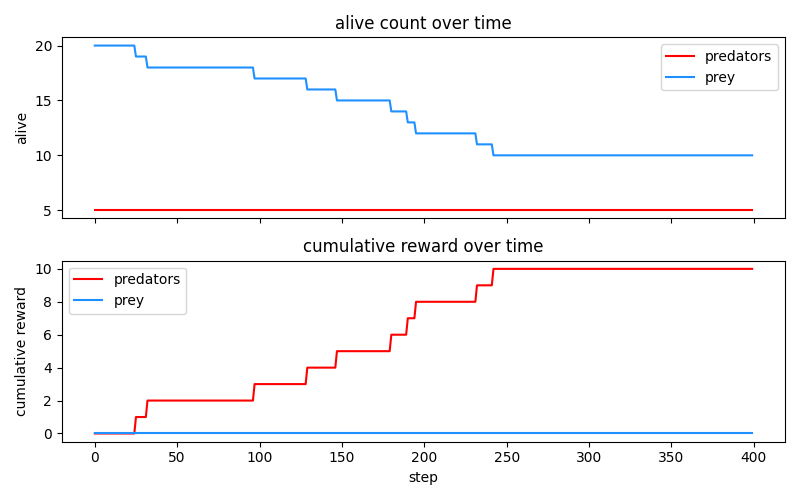

In [ ]:
_ = plot_stats(sim_before)

## Self-play

In [ ]:
cfg = PPOConfig(
    n_iters=100,
)

pred_policy, prey_policy = make_policies(seed=42)
trained_policies = train(
    env_cfg, rules,
    policies=(pred_policy, prey_policy),
    trainees=(
        Trainee(team_idx=0, reward_fn=PredatorReward()),
        Trainee(team_idx=1, reward_fn=PreyReward()),
    ),
    key=jax.random.key(1),
    cfg=cfg,
)

iter    0 | predators: loss 0.0623 reward 6.49 score 7.60 | prey: loss -0.0058 reward 3.32 score 0.00
iter    1 | predators: loss 0.0766 reward 6.31 score 7.40 | prey: loss -0.0069 reward 3.28 score 0.00


## After training

In [ ]:
sim_after = run_episode(env_cfg, rules, jax.random.key(0), trained_policies)
_ = animate(sim_after)

In [ ]:
_ = plot_stats(sim_after)

In [ ]:
from flock.env.serialize import save
save(sim_after, "selfplay")
plot = animate(sim_after)
plot.save("selfplay.mp4", writer="ffmpeg", fps=30)